In [115]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from syc.utilities import statistics
from scipy.stats import wilcoxon,mannwhitneyu

In [116]:
match_2022_12_22=pd.read_csv('C:\\Users\\dawit\\PycharmProjects\\hydration break\\data\\2022_cleaned\\2022_12_22.csv',index_col='match_time')
match_2022_12_22.index=pd.to_timedelta(match_2022_12_22.index)
match_2022_22_32=pd.read_csv('C:\\Users\\dawit\\PycharmProjects\\hydration break\\data\\2022_cleaned\\2022_22_32.csv',index_col='match_time')
match_2022_22_32.index=pd.to_timedelta(match_2022_22_32.index)
match_2022_57_67=pd.read_csv('C:\\Users\\dawit\\PycharmProjects\\hydration break\\data\\2022_cleaned\\2022_57_67.csv',index_col='match_time')
match_2022_57_67.index=pd.to_timedelta(match_2022_57_67.index)
match_2022_57_67=match_2022_57_67[match_2022_57_67['period']!=1]
match_2022_67_77=pd.read_csv('C:\\Users\\dawit\\PycharmProjects\\hydration break\\data\\2022_cleaned\\2022_67_77.csv',index_col='match_time')
match_2022_67_77.index=pd.to_timedelta(match_2022_67_77.index)

In [118]:
match_comp_2026_first=pd.read_csv('C:\\Users\\dawit\\PycharmProjects\\hydration break\\data\\match_comp_first.csv')
match_comp_2026_second=pd.read_csv('C:\\Users\\dawit\\PycharmProjects\\hydration break\\data\\match_comp_second.csv')

In [119]:
match_2022_12_22.head()

,period,minute,second,play_pattern,team,match_id,ball_recovery,clearance,dispossessed,dribble,foul,interception,pass,shot,tackle
match_time,,,,,,,,,,,,,,,
0 days 00:12:14,1,12,14,From Goal Kick,Denmark,3857254,0,0,0,0,0,0,1,0,0
0 days 00:12:18,1,12,18,From Goal Kick,Tunisia,3857254,0,1,0,0,0,0,0,0,0
0 days 00:12:22,1,12,22,Regular Play,Tunisia,3857254,1,0,0,0,0,0,0,0,0
0 days 00:12:26,1,12,26,Regular Play,Tunisia,3857254,0,0,0,0,0,0,1,0,0
0 days 00:12:30,1,12,30,Regular Play,Tunisia,3857254,0,0,0,0,0,0,1,0,0


In [120]:
match_2022_12_22.shape

(8897, 15)

In [121]:
match_2022_12_22.info()

<class 'pandas.DataFrame'>
TimedeltaIndex: 8897 entries, 0 days 00:12:14 to 0 days 00:20:53
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   period         8897 non-null   int64
 1   minute         8897 non-null   int64
 2   second         8897 non-null   int64
 3   play_pattern   8897 non-null   str  
 4   team           8897 non-null   str  
 5   match_id       8897 non-null   int64
 6   ball_recovery  8897 non-null   int64
 7   clearance      8897 non-null   int64
 8   dispossessed   8897 non-null   int64
 9   dribble        8897 non-null   int64
 10  foul           8897 non-null   int64
 11  interception   8897 non-null   int64
 12  pass           8897 non-null   int64
 13  shot           8897 non-null   int64
 14  tackle         8897 non-null   int64
dtypes: int64(13), str(2)
memory usage: 1.1 MB


In [122]:
match_2022_12_22.nunique()

period            1
minute           10
second           60
play_pattern      9
team             32
match_id         64
ball_recovery     2
clearance         2
dispossessed      2
dribble           2
foul              2
interception      2
pass              2
shot              2
tackle            2
dtype: int64

In [123]:
match_2022_12_22.groupby('match_id').agg({'team':'nunique'}).team.value_counts()

team
2    64
Name: count, dtype: int64

In [124]:
match_2022_22_32.head()

,period,minute,second,play_pattern,team,match_id,ball_recovery,clearance,dispossessed,dribble,foul,interception,pass,shot,tackle
match_time,,,,,,,,,,,,,,,
0 days 00:22:00,1,22,0,From Corner,Tunisia,3857254,0,1,0,0,0,0,0,0,0
0 days 00:22:01,1,22,1,From Corner,Denmark,3857254,0,0,0,0,0,0,1,0,0
0 days 00:22:04,1,22,4,From Corner,Denmark,3857254,0,0,0,0,0,0,1,0,0
0 days 00:22:05,1,22,5,From Corner,Denmark,3857254,0,0,0,0,0,0,0,1,0
0 days 00:22:06,1,22,6,From Corner,Tunisia,3857254,0,1,0,0,0,0,0,0,0


In [125]:
match_2022_22_32.shape

(8743, 15)

In [126]:
match_2022_22_32.info()

<class 'pandas.DataFrame'>
TimedeltaIndex: 8743 entries, 0 days 00:22:00 to 0 days 00:31:35
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   period         8743 non-null   int64
 1   minute         8743 non-null   int64
 2   second         8743 non-null   int64
 3   play_pattern   8743 non-null   str  
 4   team           8743 non-null   str  
 5   match_id       8743 non-null   int64
 6   ball_recovery  8743 non-null   int64
 7   clearance      8743 non-null   int64
 8   dispossessed   8743 non-null   int64
 9   dribble        8743 non-null   int64
 10  foul           8743 non-null   int64
 11  interception   8743 non-null   int64
 12  pass           8743 non-null   int64
 13  shot           8743 non-null   int64
 14  tackle         8743 non-null   int64
dtypes: int64(13), str(2)
memory usage: 1.1 MB


In [127]:
match_2022_22_32.nunique()

period            1
minute           10
second           60
play_pattern      9
team             32
match_id         64
ball_recovery     2
clearance         2
dispossessed      2
dribble           2
foul              2
interception      2
pass              2
shot              2
tackle            2
dtype: int64

In [128]:
match_2022_22_32.groupby('match_id').agg({'team':'nunique'}).team.value_counts()

team
2    64
Name: count, dtype: int64

In [129]:
match_2022_57_67.head()

,period,minute,second,play_pattern,team,match_id,ball_recovery,clearance,dispossessed,dribble,foul,interception,pass,shot,tackle
match_time,,,,,,,,,,,,,,,
0 days 00:57:00,2,57,0,From Throw In,Denmark,3857254,0,0,0,0,0,0,1,0,0
0 days 00:57:04,2,57,4,From Throw In,Denmark,3857254,0,0,0,0,0,0,1,0,0
0 days 00:57:08,2,57,8,Regular Play,Tunisia,3857254,1,0,0,0,0,0,0,0,0
0 days 00:57:14,2,57,14,Regular Play,Tunisia,3857254,0,0,0,0,0,0,1,0,0
0 days 00:57:18,2,57,18,Regular Play,Tunisia,3857254,0,0,0,0,0,0,1,0,0


In [130]:
match_2022_57_67.shape

(8073, 15)

In [131]:
match_2022_57_67.info()

<class 'pandas.DataFrame'>
TimedeltaIndex: 8073 entries, 0 days 00:57:00 to 0 days 01:06:50
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   period         8073 non-null   int64
 1   minute         8073 non-null   int64
 2   second         8073 non-null   int64
 3   play_pattern   8073 non-null   str  
 4   team           8073 non-null   str  
 5   match_id       8073 non-null   int64
 6   ball_recovery  8073 non-null   int64
 7   clearance      8073 non-null   int64
 8   dispossessed   8073 non-null   int64
 9   dribble        8073 non-null   int64
 10  foul           8073 non-null   int64
 11  interception   8073 non-null   int64
 12  pass           8073 non-null   int64
 13  shot           8073 non-null   int64
 14  tackle         8073 non-null   int64
dtypes: int64(13), str(2)
memory usage: 1009.1 KB


In [132]:
match_2022_57_67.nunique()

period            1
minute           10
second           60
play_pattern      9
team             32
match_id         64
ball_recovery     2
clearance         2
dispossessed      2
dribble           2
foul              2
interception      2
pass              2
shot              2
tackle            2
dtype: int64

In [133]:
match_2022_57_67.groupby('match_id').agg({'team':'nunique'}).team.value_counts()

team
2    64
Name: count, dtype: int64

In [134]:
match_2022_57_67.tail(5)

,period,minute,second,play_pattern,team,match_id,ball_recovery,clearance,dispossessed,dribble,foul,interception,pass,shot,tackle
match_time,,,,,,,,,,,,,,,
0 days 01:06:45,2,66,45,Regular Play,France,3869685,0,0,0,0,0,0,1,0,0
0 days 01:06:46,2,66,46,Regular Play,France,3869685,0,0,0,0,0,0,1,0,0
0 days 01:06:47,2,66,47,Regular Play,France,3869685,0,0,0,0,0,0,1,0,0
0 days 01:06:49,2,66,49,Regular Play,France,3869685,0,0,0,0,0,0,1,0,0
0 days 01:06:50,2,66,50,Regular Play,Argentina,3869685,0,1,0,0,0,0,0,0,0


In [135]:
match_2022_67_77.head()

,period,minute,second,play_pattern,team,match_id,ball_recovery,clearance,dispossessed,dribble,foul,interception,pass,shot,tackle
match_time,,,,,,,,,,,,,,,
0 days 01:07:02,2,67,2,From Free Kick,Denmark,3857254,0,0,0,0,0,0,1,0,0
0 days 01:07:05,2,67,5,From Free Kick,Denmark,3857254,0,0,0,0,0,0,1,0,0
0 days 01:07:07,2,67,7,From Free Kick,Tunisia,3857254,0,0,0,0,0,1,0,0,0
0 days 01:07:18,2,67,18,From Throw In,Denmark,3857254,0,0,0,0,0,0,1,0,0
0 days 01:07:21,2,67,21,From Throw In,Denmark,3857254,0,0,0,0,0,0,1,0,0


In [136]:
match_2022_67_77.shape

(7838, 15)

In [137]:
match_2022_67_77.info()

<class 'pandas.DataFrame'>
TimedeltaIndex: 7838 entries, 0 days 01:07:02 to 0 days 01:16:57
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   period         7838 non-null   int64
 1   minute         7838 non-null   int64
 2   second         7838 non-null   int64
 3   play_pattern   7838 non-null   str  
 4   team           7838 non-null   str  
 5   match_id       7838 non-null   int64
 6   ball_recovery  7838 non-null   int64
 7   clearance      7838 non-null   int64
 8   dispossessed   7838 non-null   int64
 9   dribble        7838 non-null   int64
 10  foul           7838 non-null   int64
 11  interception   7838 non-null   int64
 12  pass           7838 non-null   int64
 13  shot           7838 non-null   int64
 14  tackle         7838 non-null   int64
dtypes: int64(13), str(2)
memory usage: 979.8 KB


In [138]:
match_2022_67_77.nunique()

period            1
minute           10
second           60
play_pattern      9
team             32
match_id         64
ball_recovery     2
clearance         2
dispossessed      2
dribble           2
foul              2
interception      2
pass              2
shot              2
tackle            2
dtype: int64

In [139]:
match_2022_67_77.groupby('match_id').agg({'team':'nunique'}).team.value_counts()

team
2    64
Name: count, dtype: int64

In [140]:
total_2022_12_22=match_2022_12_22.resample('10min').sum(numeric_only=True).drop(columns=['match_id','period','minute','second'])
total_2022_12_22

,ball_recovery,clearance,dispossessed,dribble,foul,interception,pass,shot,tackle
match_time,,,,,,,,,
0 days 00:12:00,562,225,164,157,159,133,7157,107,233


In [141]:
total_2022_22_32=match_2022_22_32.resample('10min').sum(numeric_only=True).drop(columns=['match_id','period','minute','second'])
total_2022_22_32

,ball_recovery,clearance,dispossessed,dribble,foul,interception,pass,shot,tackle
match_time,,,,,,,,,
0 days 00:22:00,525,230,132,173,191,143,7030,113,206


In [142]:
total_2022_57_67=match_2022_57_67.resample('10min').sum(numeric_only=True).drop(columns=['match_id','period','minute','second'])
total_2022_57_67

,ball_recovery,clearance,dispossessed,dribble,foul,interception,pass,shot,tackle
match_time,,,,,,,,,
0 days 00:57:00,549,255,127,176,159,140,6314,147,206


In [143]:
total_2022_67_77=match_2022_67_77.resample('10min').sum(numeric_only=True).drop(columns=['match_id','period','minute','second'])
total_2022_67_77

,ball_recovery,clearance,dispossessed,dribble,foul,interception,pass,shot,tackle
match_time,,,,,,,,,
0 days 01:07:00,546,245,133,171,171,138,6068,158,208


In [144]:
for column in total_2022_12_22.columns:
    print(f'total_12_22 {column} relative composition(%)')
    print(f'{(total_2022_12_22[column].iloc[0]/(total_2022_12_22[column].iloc[0]+total_2022_22_32[column].iloc[0]+total_2022_57_67[column].iloc[0]+total_2022_67_77[column].iloc[0]))*100}%')
    print(f'total_22_32 {column} relative composition(%)')
    print(f'{(total_2022_22_32[column].iloc[0]/(total_2022_12_22[column].iloc[0]+total_2022_22_32[column].iloc[0]+total_2022_57_67[column].iloc[0]+total_2022_67_77[column].iloc[0]))*100}%')
    print(f'total_57_67 {column} relative composition(%)')
    print(f'{(total_2022_57_67[column].iloc[0]/(total_2022_12_22[column].iloc[0]+total_2022_22_32[column].iloc[0]+total_2022_57_67[column].iloc[0]+total_2022_57_67[column].iloc[0]))*100}%')
    print(f'total_67_77 {column} relative composition(%)')
    print(f'{(total_2022_57_67[column].iloc[0]/(total_2022_12_22[column].iloc[0]+total_2022_22_32[column].iloc[0]+total_2022_57_67[column].iloc[0]+total_2022_67_77[column].iloc[0]))*100}%')

total_12_22 ball_recovery relative composition(%)
25.756186984417965%
total_22_32 ball_recovery relative composition(%)
24.060494958753438%
total_57_67 ball_recovery relative composition(%)
25.125858123569795%
total_67_77 ball_recovery relative composition(%)
25.16040329972502%
total_12_22 clearance relative composition(%)
23.56020942408377%
total_22_32 clearance relative composition(%)
24.083769633507853%
total_57_67 clearance relative composition(%)
26.42487046632124%
total_67_77 clearance relative composition(%)
26.701570680628272%
total_12_22 dispossessed relative composition(%)
29.496402877697843%
total_22_32 dispossessed relative composition(%)
23.741007194244602%
total_57_67 dispossessed relative composition(%)
23.09090909090909%
total_67_77 dispossessed relative composition(%)
22.841726618705035%
total_12_22 dribble relative composition(%)
23.190546528803544%
total_22_32 dribble relative composition(%)
25.553914327917283%
total_57_67 dribble relative composition(%)
25.806451612

In [145]:
total_2022_12_22['total_12_22']=total_2022_12_22.sum(axis=1)
total_2022_22_32['total_22_32']=total_2022_22_32.sum(axis=1)
total_2022_57_67['total_57_67']=total_2022_57_67.sum(axis=1)
total_2022_67_77['total_67_77']=total_2022_67_77.sum(axis=1)

In [146]:
total_2022_12_22.total_12_22

match_time
0 days 00:12:00    8897
Freq: 10min, Name: total_12_22, dtype: int64

In [147]:
total_2022_22_32.total_22_32

match_time
0 days 00:22:00    8743
Freq: 10min, Name: total_22_32, dtype: int64

In [148]:
total_2022_57_67.total_57_67

match_time
0 days 00:57:00    8073
Freq: 10min, Name: total_57_67, dtype: int64

In [149]:
total_2022_67_77.total_67_77

match_time
0 days 01:07:00    7838
Freq: 10min, Name: total_67_77, dtype: int64

In [150]:
for i in ['period','minute','second']:
    match_2022_12_22[i]=match_2022_12_22[i].astype(str)
    match_2022_22_32[i]=match_2022_22_32[i].astype(str)
    match_2022_57_67[i]=match_2022_57_67[i].astype(str)
    match_2022_67_77[i]=match_2022_67_77[i].astype(str)

In [151]:
match_by_match_id_2022_12_22 =match_2022_12_22.groupby('match_id').sum(numeric_only=True)
match_by_match_id_2022_12_22['total'] = match_by_match_id_2022_12_22.sum(axis=1)
match_by_match_id_2022_22_32 =match_2022_22_32.groupby('match_id').sum(numeric_only=True)
match_by_match_id_2022_22_32['total'] = match_by_match_id_2022_22_32.sum(axis=1)
match_by_match_id_2022_57_67 = match_2022_57_67.groupby('match_id').sum(numeric_only=True)
match_by_match_id_2022_57_67['total'] = match_by_match_id_2022_57_67.sum(axis=1)
match_by_match_id_2022_67_77 = match_2022_67_77.groupby('match_id').sum(numeric_only=True)
match_by_match_id_2022_67_77['total'] = match_by_match_id_2022_67_77.sum(axis=1)

In [152]:
match_by_match_id_2022_12_22.head()

,ball_recovery,clearance,dispossessed,dribble,foul,interception,pass,shot,tackle,total
match_id,,,,,,,,,,
3857254,12,9,1,6,2,0,98,0,5,133
3857255,7,3,3,1,2,3,179,0,4,202
3857256,9,8,4,1,4,2,90,3,4,125
3857257,5,3,1,3,2,3,111,2,4,134
3857258,4,0,1,4,3,2,131,3,3,151


In [153]:
print(match_by_match_id_2022_12_22.shape)
print(match_by_match_id_2022_22_32.shape)
print(match_by_match_id_2022_57_67.shape)
print(match_by_match_id_2022_67_77.shape)

(64, 10)
(64, 10)
(64, 10)
(64, 10)


In [154]:
stat_2022_12_22=statistics(match_by_match_id_2022_12_22['total'])
stat_2022_12_22

,mean,count,standard deviation,minimum,median,maximum,25th quartile,75th quartile,IQR
0,139.015625,64,30.96157,45,141.5,202,128.25,157.25,29.0


In [155]:
stat_2022_22_32=statistics(match_by_match_id_2022_22_32['total'])
stat_2022_22_32

,mean,count,standard deviation,minimum,median,maximum,25th quartile,75th quartile,IQR
0,136.609375,64,24.01958,81,139.0,184,120.75,151.25,30.5


In [156]:
stat_2022_57_67=statistics(match_by_match_id_2022_57_67['total'])
stat_2022_57_67

,mean,count,standard deviation,minimum,median,maximum,25th quartile,75th quartile,IQR
0,126.140625,64,22.72602,73,126.0,179,109.0,139.25,30.25


In [157]:
stat_2022_67_77=statistics(match_by_match_id_2022_67_77['total'])
stat_2022_67_77

,mean,count,standard deviation,minimum,median,maximum,25th quartile,75th quartile,IQR
0,122.46875,64,29.160731,60,126.0,177,99.5,147.25,47.75


In [158]:
first_half_control=(pd.concat([total_2022_12_22.assign(window='12-22'),total_2022_22_32.assign(window='22-32')])).melt(value_vars=['shot','ball_recovery','clearance','dispossessed','foul','interception','pass','tackle','dribble'],id_vars='window').pivot(index='variable',values='value',columns='window').assign(change_first_control=lambda x:x['22-32']-x['12-22'])
first_half_control

window,12-22,22-32,change_first_control
variable,,,
ball_recovery,562,525,-37
clearance,225,230,5
dispossessed,164,132,-32
dribble,157,173,16
foul,159,191,32
interception,133,143,10
pass,7157,7030,-127
shot,107,113,6
tackle,233,206,-27


In [159]:
second_half_control=(pd.concat([total_2022_57_67.assign(window='57-67'),total_2022_67_77.assign(window='67-77')])).melt(value_vars=['shot','ball_recovery','clearance','dispossessed','foul','interception','pass','tackle','dribble'],id_vars='window').pivot(index='variable',values='value',columns='window').assign(change_second_control=lambda x:x['67-77']-x['57-67'])
second_half_control

window,57-67,67-77,change_second_control
variable,,,
ball_recovery,549,546,-3
clearance,255,245,-10
dispossessed,127,133,6
dribble,176,171,-5
foul,159,171,12
interception,140,138,-2
pass,6314,6068,-246
shot,147,158,11
tackle,206,208,2


In [160]:
pd.concat([first_half_control['change_first_control'],second_half_control['change_second_control']],axis=1)

,change_first_control,change_second_control
variable,,
ball_recovery,-37,-3
clearance,5,-10
dispossessed,-32,6
dribble,16,-5
foul,32,12
interception,10,-2
pass,-127,-246
shot,6,11
tackle,-27,2


In [161]:
first_control_stats=(pd.concat([stat_2022_12_22.assign(window='12-22'),stat_2022_22_32.assign(window='22-32')])).melt(value_vars=['mean','median','standard deviation','maximum','minimum','25th quartile','75th quartile','IQR'],id_vars='window').pivot(index='variable',values='value',columns='window').assign(change_first_control=lambda x:x['22-32']-x['12-22'])
first_control_stats

window,12-22,22-32,change_first_control
variable,,,
25th quartile,128.250000,120.750000,-7.50000
75th quartile,157.250000,151.250000,-6.00000
IQR,29.000000,30.500000,1.50000
maximum,202.000000,184.000000,-18.00000
mean,139.015625,136.609375,-2.40625
median,141.500000,139.000000,-2.50000
minimum,45.000000,81.000000,36.00000
standard deviation,30.961570,24.019580,-6.94199


In [162]:
second_control_stats=(pd.concat([stat_2022_57_67.assign(window='57-67'),stat_2022_67_77.assign(window='67-77')])).melt(value_vars=['mean','median','standard deviation','maximum','minimum','25th quartile','75th quartile','IQR'],id_vars='window').pivot(index='variable',values='value',columns='window').assign(change_second_control=lambda x:x['67-77']-x['57-67'])
second_control_stats

window,57-67,67-77,change_second_control
variable,,,
25th quartile,109.000000,99.500000,-9.500000
75th quartile,139.250000,147.250000,8.000000
IQR,30.250000,47.750000,17.500000
maximum,179.000000,177.000000,-2.000000
mean,126.140625,122.468750,-3.671875
median,126.000000,126.000000,0.000000
minimum,73.000000,60.000000,-13.000000
standard deviation,22.726020,29.160731,6.434711


In [163]:
pd.concat([first_control_stats['change_first_control'],second_control_stats['change_second_control']],axis=1)

,change_first_control,change_second_control
variable,,
25th quartile,-7.50000,-9.500000
75th quartile,-6.00000,8.000000
IQR,1.50000,17.500000
maximum,-18.00000,-2.000000
mean,-2.40625,-3.671875
median,-2.50000,0.000000
minimum,36.00000,-13.000000
standard deviation,-6.94199,6.434711


In [164]:
match_comp_first_control = pd.concat([
    match_by_match_id_2022_12_22['total'].rename('total_12_22'),
    match_by_match_id_2022_22_32['total'].rename('total_22_32')
], axis=1).assign(
    change_first_control=lambda x: x['total_22_32'] - x['total_12_22'],
    categorical_change=lambda x:np.select(
        [
            x['change_first_control']>0,x['change_first_control']<0
        ],['increase','decrease'],default='unchanged'
    )
)
match_comp_first_control['categorical_change'].value_counts()

categorical_change
decrease    33
increase    31
Name: count, dtype: int64

Text(0.5, 1.0, 'match-to-match changes in the first half control of 2022')

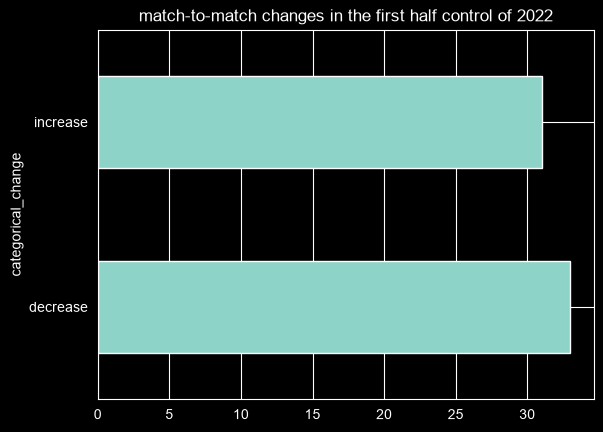

In [165]:
ax=match_comp_first_control['categorical_change'].value_counts().plot(kind='barh')
ax.set_title('match-to-match changes in the first half control of 2022')

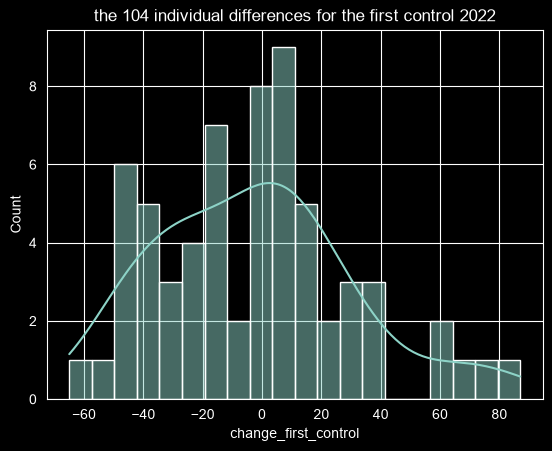

In [166]:
ax=sns.histplot(match_comp_first_control.change_first_control,kde=True,bins=20)
ax.set_title('the 104 individual differences for the first control 2022')
plt.savefig('C:\\Users\\dawit\\PycharmProjects\\hydration break\\images\\histogram_first_control.png',dpi=300,bbox_inches='tight')
plt.show()

Text(0.5, 1.0, 'box plot of 64 individual difference from the first half control 2022')

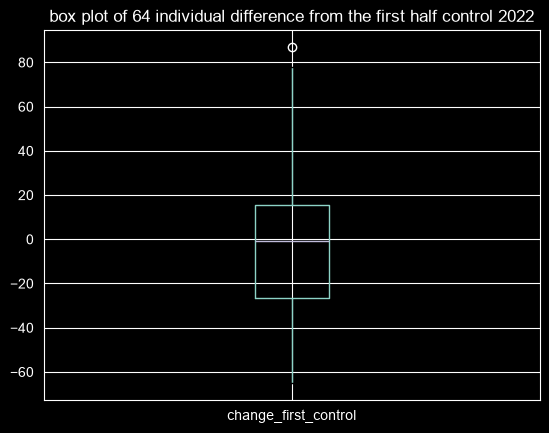

In [167]:
ax=match_comp_first_control.boxplot(column='change_first_control')
ax.set_title('box plot of 64 individual difference from the first half control 2022')

In [168]:
match_comp_second_control = pd.concat([
    match_by_match_id_2022_57_67['total'].rename('total_57_67'),
    match_by_match_id_2022_67_77['total'].rename('total_67_77')
], axis=1).assign(
    change_second_control=lambda x: x['total_67_77'] - x['total_57_67'],
    categorical_change=lambda x:np.select(
        [
            x['change_second_control']>0,x['change_second_control']<0
        ],['increase','decrease'],default='unchanged'
    )
)
match_comp_second_control['categorical_change'].value_counts()

categorical_change
decrease    36
increase    28
Name: count, dtype: int64

Text(0.5, 1.0, 'match-to-match changes in the second half control of 2022')

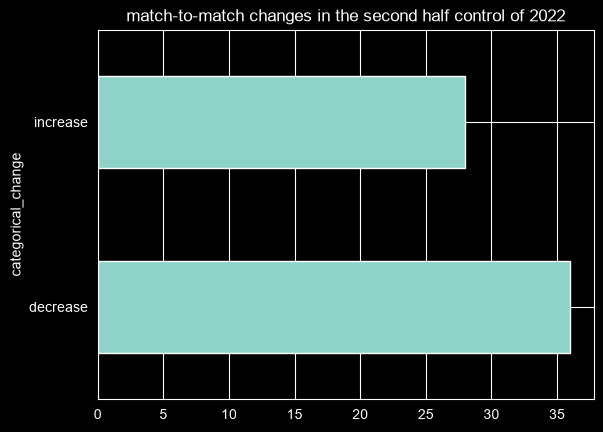

In [169]:
ax=match_comp_second_control['categorical_change'].value_counts().plot(kind='barh')
ax.set_title('match-to-match changes in the second half control of 2022')

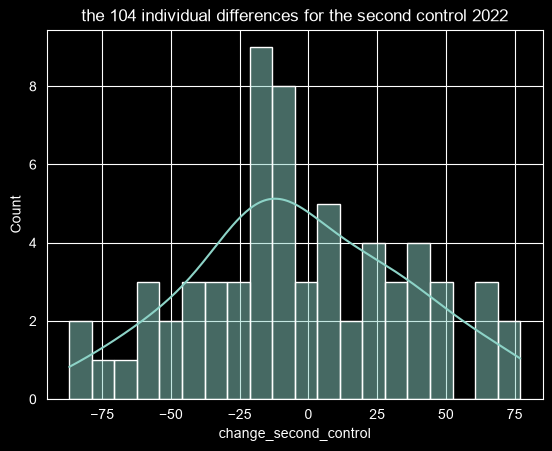

In [170]:
ax=sns.histplot(match_comp_second_control['change_second_control'],kde=True,bins=20)
ax.set_title('the 104 individual differences for the second control 2022')
plt.savefig('C:\\Users\\dawit\\PycharmProjects\\hydration break\\images\\histogram_second_control.png',dpi=300,bbox_inches='tight')
plt.show()

Text(0.5, 1.0, 'box plot of 64 individual difference from the second half control 2022')

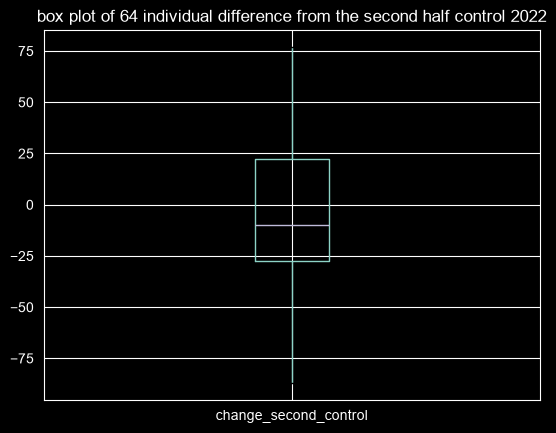

In [171]:
ax=match_comp_second_control.boxplot(column='change_second_control')
ax.set_title('box plot of 64 individual difference from the second half control 2022')

In [172]:
match_2022_changes=(pd.concat([statistics(match_comp_first_control['change_first_control']).assign(window='first_half_control'),statistics(match_comp_second_control['change_second_control']).assign(window='second_half_control')])).melt(value_vars=['mean','median','standard deviation','maximum','minimum','25th quartile','75th quartile','IQR'],id_vars='window').pivot(index='variable',values='value',columns='window')
match_2022_changes

window,first_half_control,second_half_control
variable,,
25th quartile,-26.500000,-27.500000
75th quartile,15.500000,22.500000
IQR,42.000000,50.000000
maximum,87.000000,77.000000
mean,-2.406250,-3.671875
median,-1.000000,-10.000000
minimum,-65.000000,-87.000000
standard deviation,33.266466,39.053506


In [173]:
result_first_control=wilcoxon(match_comp_first_control['total_12_22'],match_comp_first_control['total_22_32'],alternative='two-sided',
    method='approx')
print('statistic:',result_first_control.statistic)
print('p-value:',result_first_control.pvalue)
print('z-statistic:',result_first_control.zstatistic)

statistic: 906.5
p-value: 0.3719138358910804
z-statistic: -0.8928941953976396


In [174]:
result_second_control=wilcoxon(match_comp_second_control['total_57_67'],match_comp_second_control['total_67_77'],alternative='two-sided',method='approx')
print('statistic:',result_second_control.statistic)
print('p-value:',result_second_control.pvalue)
print('z-statistic:',result_second_control.zstatistic)

statistic: 924.5
p-value: 0.43983262090741926
z-statistic: -0.7724758906336857


In [175]:
n_first_control=len(match_comp_first_control)
r_first_control=np.abs(result_first_control.zstatistic)/np.sqrt(n_first_control)
print('first control')
print("N:",n_first_control)
print('r:',r_first_control)

first control
N: 64
r: 0.11161177442470495


In [176]:
n_second_control=len(match_comp_second_control)
r_second_control=np.abs(result_second_control.zstatistic)/np.sqrt(n_second_control)
print('first break')
print("N:",n_second_control)
print('r:',r_second_control)

first break
N: 64
r: 0.09655948632921071


In [177]:
alpha=0.05
number_of_tests=2
corrected_alpha=alpha/number_of_tests
corrected_alpha

0.025

In [178]:
match_2026_changes=(pd.concat([statistics(match_comp_2026_first['change_first']).assign(window='first_break'),statistics(match_comp_2026_second['change_second']).assign(window='second_break')])).melt(value_vars=['mean','median','standard deviation','maximum','minimum','25th quartile','75th quartile','IQR'],id_vars='window').pivot(index='variable',values='value',columns='window')
match_2026_changes

window,first_break,second_break
variable,,
25th quartile,-39.750000,-36.000000
75th quartile,9.500000,14.750000
IQR,49.250000,50.750000
maximum,88.000000,100.000000
mean,-16.807692,-8.288462
median,-19.500000,-6.000000
minimum,-87.000000,-109.000000
standard deviation,34.766929,38.016009


In [179]:
pd.concat([match_2026_changes['first_break'].rename('first_break_2026'),match_2022_changes['first_half_control'].rename('first_control_2022')],axis=1)

,first_break_2026,first_control_2022
variable,,
25th quartile,-39.750000,-26.500000
75th quartile,9.500000,15.500000
IQR,49.250000,42.000000
maximum,88.000000,87.000000
mean,-16.807692,-2.406250
median,-19.500000,-1.000000
minimum,-87.000000,-65.000000
standard deviation,34.766929,33.266466


In [180]:
pd.concat([match_2026_changes['second_break'].rename('second_break_2026'),match_2022_changes['second_half_control'].rename('second_control_2022')],axis=1)

,second_break_2026,second_control_2022
variable,,
25th quartile,-36.000000,-27.500000
75th quartile,14.750000,22.500000
IQR,50.750000,50.000000
maximum,100.000000,77.000000
mean,-8.288462,-3.671875
median,-6.000000,-10.000000
minimum,-109.000000,-87.000000
standard deviation,38.016009,39.053506


In [181]:
statistic_first,p_value_first=mannwhitneyu(match_comp_first_control['change_first_control'],match_comp_2026_first['change_first'],alternative='two-sided')
print('statistic',statistic_first)
print('p-value',p_value_first)

statistic 4072.5
p-value 0.015088161735454731


In [182]:
statistic_second,p_value_second=mannwhitneyu(match_comp_second_control['change_second_control'],match_comp_2026_second['change_second'],alternative='two-sided')
print('statistic',statistic_second)
print('p-value',p_value_second)

statistic 3503.0
p-value 0.5686821571009701


In [183]:
n1_first = match_comp_first_control['change_first_control'].count()
n2_first = match_comp_2026_first['change_first'].count()
n1_second = match_comp_second_control['change_second_control'].count()
n2_second = match_comp_2026_second['change_second'].count()
r_rb_first = 1 - (
    2 * statistic_first / (n1_first * n2_first)
)
r_rb_second = 1 - (
    2 * statistic_second / (n1_second * n2_second)
)
print('First-period rank-biserial correlation:', r_rb_first)
print('Second-period rank-biserial correlation:', r_rb_second)

First-period rank-biserial correlation: -0.2237079326923077
Second-period rank-biserial correlation: -0.05258413461538458
